## Imports

In [ ]:
!pip install torchinfo

In [2]:
import os
import random
import math
import time
import pickle

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models import vgg16, VGG16_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchinfo import summary

import pandas as pd
import matplotlib.pyplot as plt
import PIL.Image as Image

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

random.seed(42)

## Load the Dataset

In [ ]:
base_train_path = r"C:\Users\m1-ra\OneDrive - AL-Hussien bin Abdullah Technical University\Deep Learning\archive\DATASET\TRAIN"

organic_dir = os.path.join(base_train_path, "O") 
recyclable_dir = os.path.join(base_train_path, "R")

all_organic_files = os.listdir(organic_dir)
all_recyclable_files = os.listdir(recyclable_dir)

sample_size = 5000

selected_organic = random.sample(all_organic_files, sample_size)
selected_recyclable = random.sample(all_recyclable_files, sample_size)

print(f"Organic images selected: {len(selected_organic)}")
print(f"Recyclable images selected: {len(selected_recyclable)}")

Organic images selected: 5000
Recyclable images selected: 5000


In [ ]:
class WasteDataset(Dataset):
    def __init__(self,organic_dir,recyclable_dir,organic_files,recyclable_files,transform = None):
        super().__init__()

        self.transform = transform
        self.file_paths = []
        self.labels = []

        for f in organic_files:
            self.file_paths.append(os.path.join(organic_dir,f))
            self.labels.append(0)

        for f in recyclable_files:
            self.file_paths.append(os.path.join(recyclable_dir,f))
            self.labels.append(1)
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, index):
        image_path = self.file_paths[index]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image,label

: 

In [14]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [15]:
dataset = WasteDataset(
    organic_dir=organic_dir,
    recyclable_dir=recyclable_dir,
    organic_files=selected_organic,
    recyclable_files=selected_recyclable,
    transform=transform
)

print(f"Total images: {len(dataset)}")

Total images: 10000


In [16]:
organic_train_end = int(0.7 * len(selected_organic))
organic_val_end = int(0.8 * len(selected_organic))

recyclable_train_end = int(0.7 * len(selected_recyclable))
recyclable_val_end = int(0.8 * len(selected_recyclable))

train_organic = selected_organic[:organic_train_end]
val_organic = selected_organic[organic_train_end:organic_val_end]
test_organic = selected_organic[organic_val_end:]

train_recyclable = selected_recyclable[:recyclable_train_end]
val_recyclable = selected_recyclable[recyclable_train_end:recyclable_val_end]
test_recyclable = selected_recyclable[recyclable_val_end:]

print("Train organic:", len(train_organic))
print("Val organic:", len(val_organic))
print("Test organic:", len(test_organic))

print("Train recyclable:", len(train_recyclable))
print("Val recyclable:", len(val_recyclable))
print("Test recyclable:", len(test_recyclable))

Train organic: 3500
Val organic: 500
Test organic: 1000
Train recyclable: 3500
Val recyclable: 500
Test recyclable: 1000


In [17]:
train_dataset = WasteDataset(
    organic_dir, recyclable_dir,
    train_organic, train_recyclable,
    transform=transform
)

val_dataset = WasteDataset(
    organic_dir, recyclable_dir,
    val_organic, val_recyclable,
    transform=transform
)

test_dataset = WasteDataset(
    organic_dir, recyclable_dir,
    test_organic, test_recyclable,
    transform=transform
)

## Creating Data Loaders for each set

In [ ]:

def create_loaders(batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader, test_loader

## Building Hyperparameter Combinations

In [20]:
resnet18_hyperparameter_combinations = [
    {"model_name": "ResNet18_Model_1", "dropout": 0.2, "learning_rate": 0.001, "batch_size": 32, "momentum": 0.9},
    {"model_name": "ResNet18_Model_2", "dropout": 0.4, "learning_rate": 0.0005, "batch_size": 32, "momentum": 0.85},
    {"model_name": "ResNet18_Model_3", "dropout": 0.5, "learning_rate": 0.0001, "batch_size": 64, "momentum": 0.95},
]

vgg16_hyperparameter_combinations = [
    {"model_name": "VGG16_Model_1", "dropout": 0.2, "learning_rate": 0.001, "batch_size": 32, "weight_decay": 1e-4},
    {"model_name": "VGG16_Model_2", "dropout": 0.4, "learning_rate": 0.0005, "batch_size": 32, "weight_decay": 5e-4},
    {"model_name": "VGG16_Model_3", "dropout": 0.5, "learning_rate": 0.0001, "batch_size": 64, "weight_decay": 1e-3},
]

efficientnet_hyperparameter_combinations = [
    {"model_name": "EfficientNetB0_Model_1", "dropout": 0.2, "learning_rate": 0.001, "batch_size": 32, "drop_connect_rate": 0.1},
    {"model_name": "EfficientNetB0_Model_2", "dropout": 0.4, "learning_rate": 0.0005, "batch_size": 32, "drop_connect_rate": 0.2},
    {"model_name": "EfficientNetB0_Model_3", "dropout": 0.5, "learning_rate": 0.0001, "batch_size": 64, "drop_connect_rate": 0.3},
]

mobilenet_hyperparameter_combinations = [
    {"model_name": "MobileNetV2_Model_1", "dropout": 0.2, "learning_rate": 0.001, "batch_size": 32},
    {"model_name": "MobileNetV2_Model_2", "dropout": 0.4, "learning_rate": 0.0005, "batch_size": 32},
    {"model_name": "MobileNetV2_Model_3", "dropout": 0.5, "learning_rate": 0.0001, "batch_size": 64},
]

## Building Functions that will create models 

In [21]:
def create_resnet18_model(dropout):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_features, 2)
    )

    return model

def create_vgg16_model(dropout):
    model = vgg16(weights=VGG16_Weights.DEFAULT)

    # Freeze convolutional feature extractor
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace the classifier
    model.classifier = nn.Sequential(
        nn.Linear(25088, 4096),
        nn.ReLU(),
        nn.Dropout(dropout),

        nn.Linear(4096, 1024),
        nn.ReLU(),
        nn.Dropout(dropout),

        nn.Linear(1024, 2)
    )

    return model

def create_efficientnet_b0_model(dropout, drop_connect_rate=0.2):
    model = efficientnet_b0(
        weights=EfficientNet_B0_Weights.DEFAULT,
        stochastic_depth_prob=drop_connect_rate
    )

    # Freeze feature extractor
    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, 2)
    )

    return model

def create_mobilenet_v2_model(dropout):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

    # Freeze feature extractor
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace classifier
    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, 2)
    )

    return model


## A function that will train one model per time 

In [ ]:

def train_one_model(model, train_loader, val_loader, params, epochs, device):
    criterion = nn.CrossEntropyLoss()
    learning_rate = params["learning_rate"] 
    if "momentum" in params:
        optimizer = optim.SGD(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=learning_rate,
            momentum=params["momentum"]
        )

    elif "weight_decay" in params:
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=learning_rate,
            weight_decay=params["weight_decay"]
        )

    else:
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=learning_rate
        )

    model = model.to(device)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_accuracy = train_correct / train_total
        average_train_loss = train_loss / len(train_loader)

        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_accuracy = val_correct / val_total
        average_val_loss = val_loss / len(val_loader)

        history["train_loss"].append(average_train_loss)
        history["train_acc"].append(train_accuracy)
        history["val_loss"].append(average_val_loss)
        history["val_acc"].append(val_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {average_train_loss:.4f} "
            f"Train Acc: {train_accuracy:.4f} "
            f"Val Loss: {average_val_loss:.4f} "
            f"Val Acc: {val_accuracy:.4f}"
        )

    return model, history

## CREATING EXPERIMENTS

In [23]:
all_experiments = [
    {
        "architecture": "ResNet18",
        "combinations": resnet18_hyperparameter_combinations,
        "create_model": create_resnet18_model
    },
    {
        "architecture": "VGG16",
        "combinations": vgg16_hyperparameter_combinations,
        "create_model": create_vgg16_model
    },
    {
        "architecture": "EfficientNetB0",
        "combinations": efficientnet_hyperparameter_combinations,
        "create_model": create_efficientnet_b0_model
    },
    {
        "architecture": "MobileNetV2",
        "combinations": mobilenet_hyperparameter_combinations,
        "create_model": create_mobilenet_v2_model
    }
]

## Training All the Experiments

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

epochs = 10

trained_models = {}
histories = {}

for experiment in all_experiments:
    print("#" * 60)
    print("Architecture:", experiment["architecture"])
    print("#" * 60)

    for params in experiment["combinations"]:
        print("=" * 60)
        print("Training:", params["model_name"])
        print(params)

        train_loader, val_loader, test_loader = create_loaders(
            batch_size=params["batch_size"]
        )

        if "drop_connect_rate" in params:
            model = experiment["create_model"](
            dropout=params["dropout"],
            drop_connect_rate=params["drop_connect_rate"]
            )
        else:
            model = experiment["create_model"](
                    dropout=params["dropout"]
                    )

        trained_model, history = train_one_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            params=params,
            epochs=epochs,
            device=device
        )

        trained_models[params["model_name"]] = trained_model
        histories[params["model_name"]] = history

        torch.save(
            trained_model.state_dict(),
            params["model_name"] + ".pth"
        )

        print(params["model_name"], "saved successfully.")

Using device: cuda
############################################################
Architecture: ResNet18
############################################################
Training: ResNet18_Model_1
{'model_name': 'ResNet18_Model_1', 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 32, 'momentum': 0.9}
Epoch [1/10] Train Loss: 0.3231 Train Acc: 0.8574 Val Loss: 0.2139 Val Acc: 0.9170
Epoch [2/10] Train Loss: 0.2391 Train Acc: 0.9069 Val Loss: 0.2275 Val Acc: 0.9130
Epoch [3/10] Train Loss: 0.2423 Train Acc: 0.9041 Val Loss: 0.1856 Val Acc: 0.9330
Epoch [4/10] Train Loss: 0.2374 Train Acc: 0.9090 Val Loss: 0.1865 Val Acc: 0.9370
Epoch [5/10] Train Loss: 0.2436 Train Acc: 0.9060 Val Loss: 0.1837 Val Acc: 0.9300
Epoch [6/10] Train Loss: 0.2319 Train Acc: 0.9063 Val Loss: 0.1866 Val Acc: 0.9320
Epoch [7/10] Train Loss: 0.2216 Train Acc: 0.9121 Val Loss: 0.1825 Val Acc: 0.9310
Epoch [8/10] Train Loss: 0.2217 Train Acc: 0.9124 Val Loss: 0.1765 Val Acc: 0.9350
Epoch [9/10] Train Loss: 0.2288 Tra

## Saving the Histories

In [ ]:


with open("histories.pkl", "wb") as f:
    pickle.dump(histories, f)

print("Histories saved successfully.")

Histories saved successfully.


In [ ]:


with open("histories.pkl", "rb") as f:
    histories = pickle.load(f)

print("Histories loaded successfully.")

Histories loaded successfully.


## Visualizing Training vs Validation scores vs epochs to analyze over-fitting, good fitting and under-fitting 

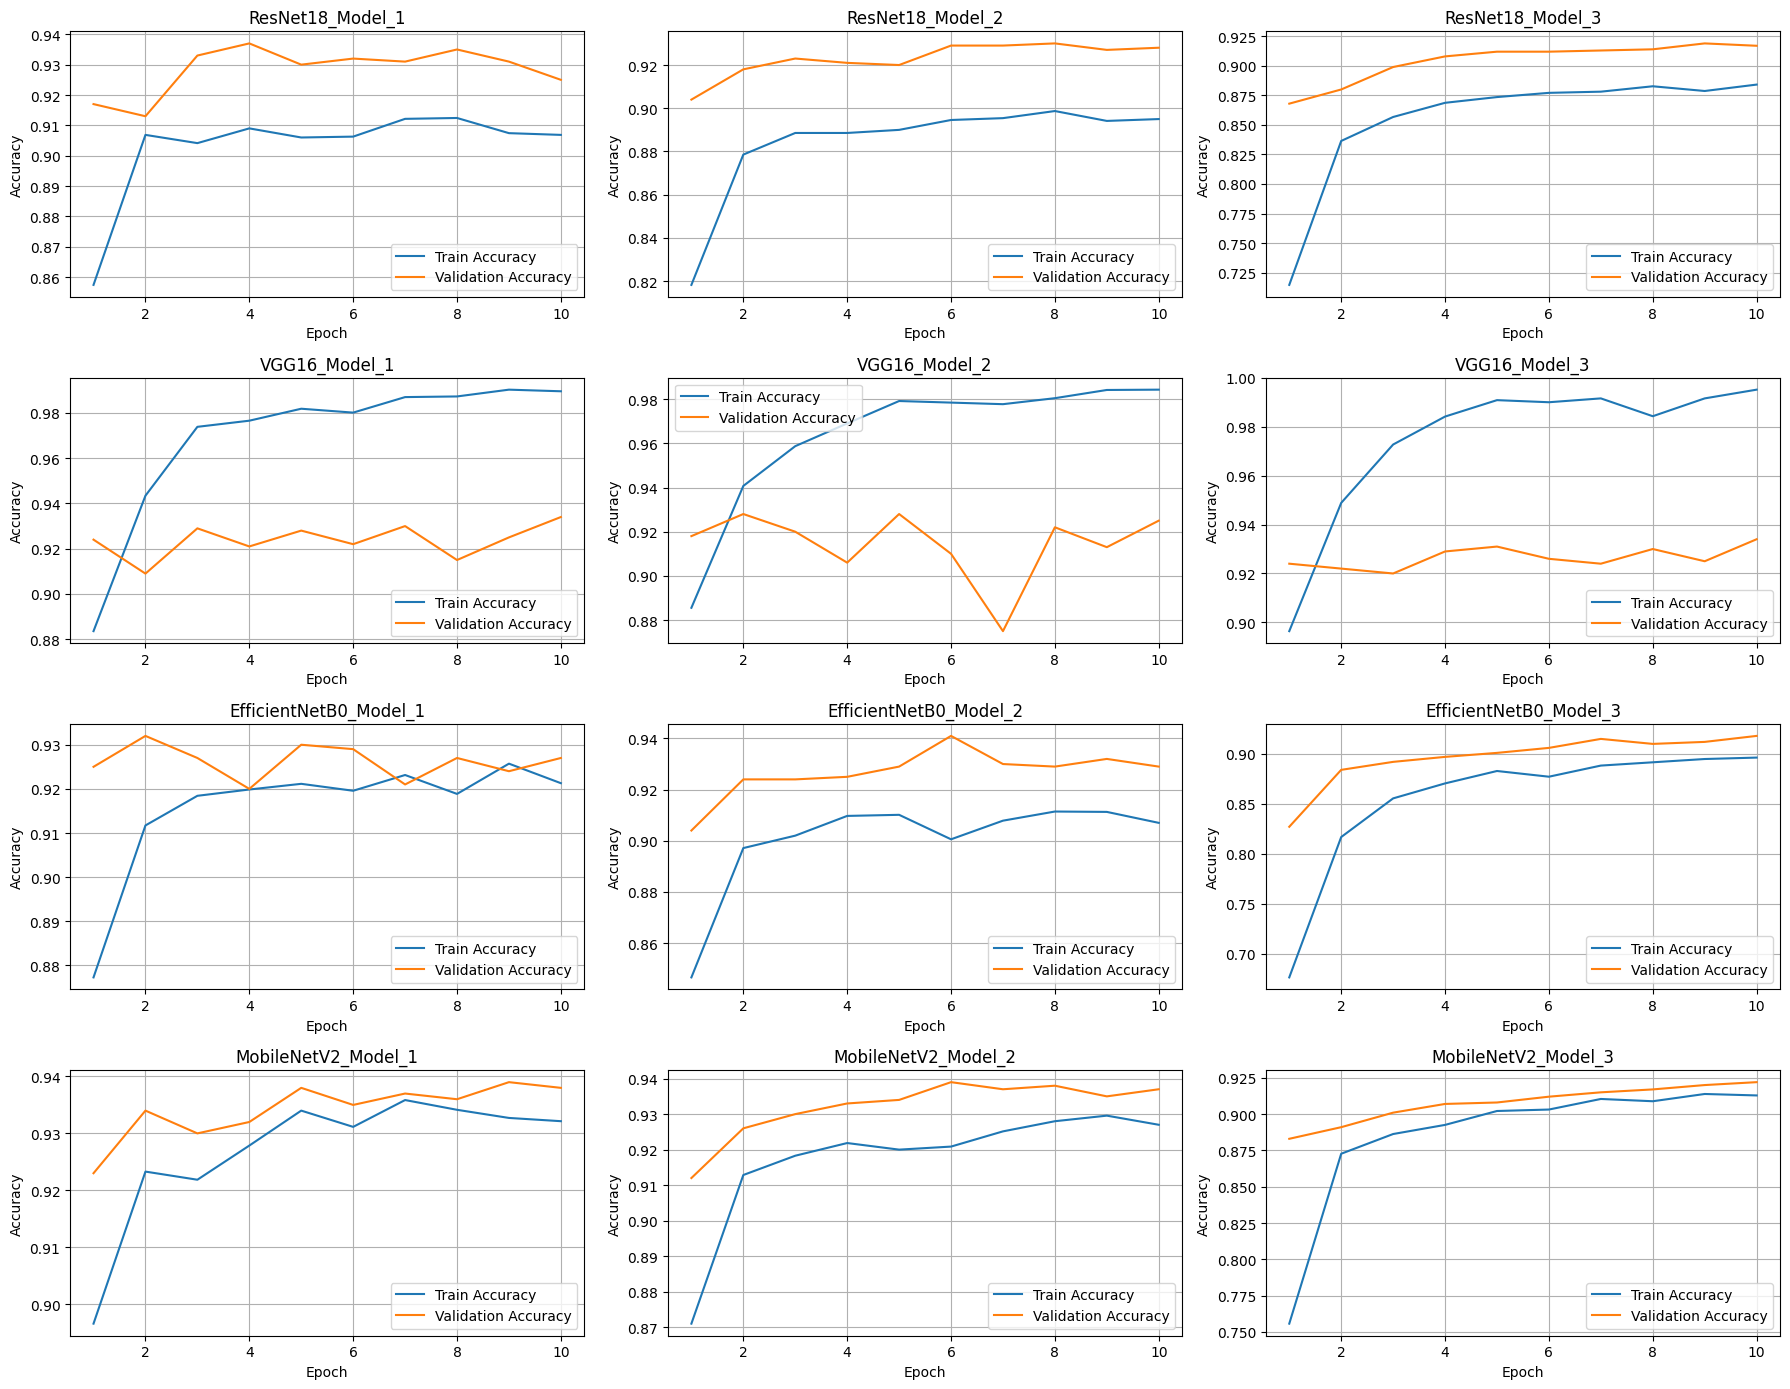

In [ ]:
metric_train = "train_acc"
metric_val = "val_acc"

fig, axes = plt.subplots(4, 3, figsize=(18, 14))

axes = axes.flatten()

for i, (model_name, history) in enumerate(histories.items()):
    ax = axes[i]

    epochs = range(1, len(history[metric_train]) + 1)

    ax.plot(epochs, history[metric_train], label="Train Accuracy")
    ax.plot(epochs, history[metric_val], label="Validation Accuracy")

    ax.set_title(model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

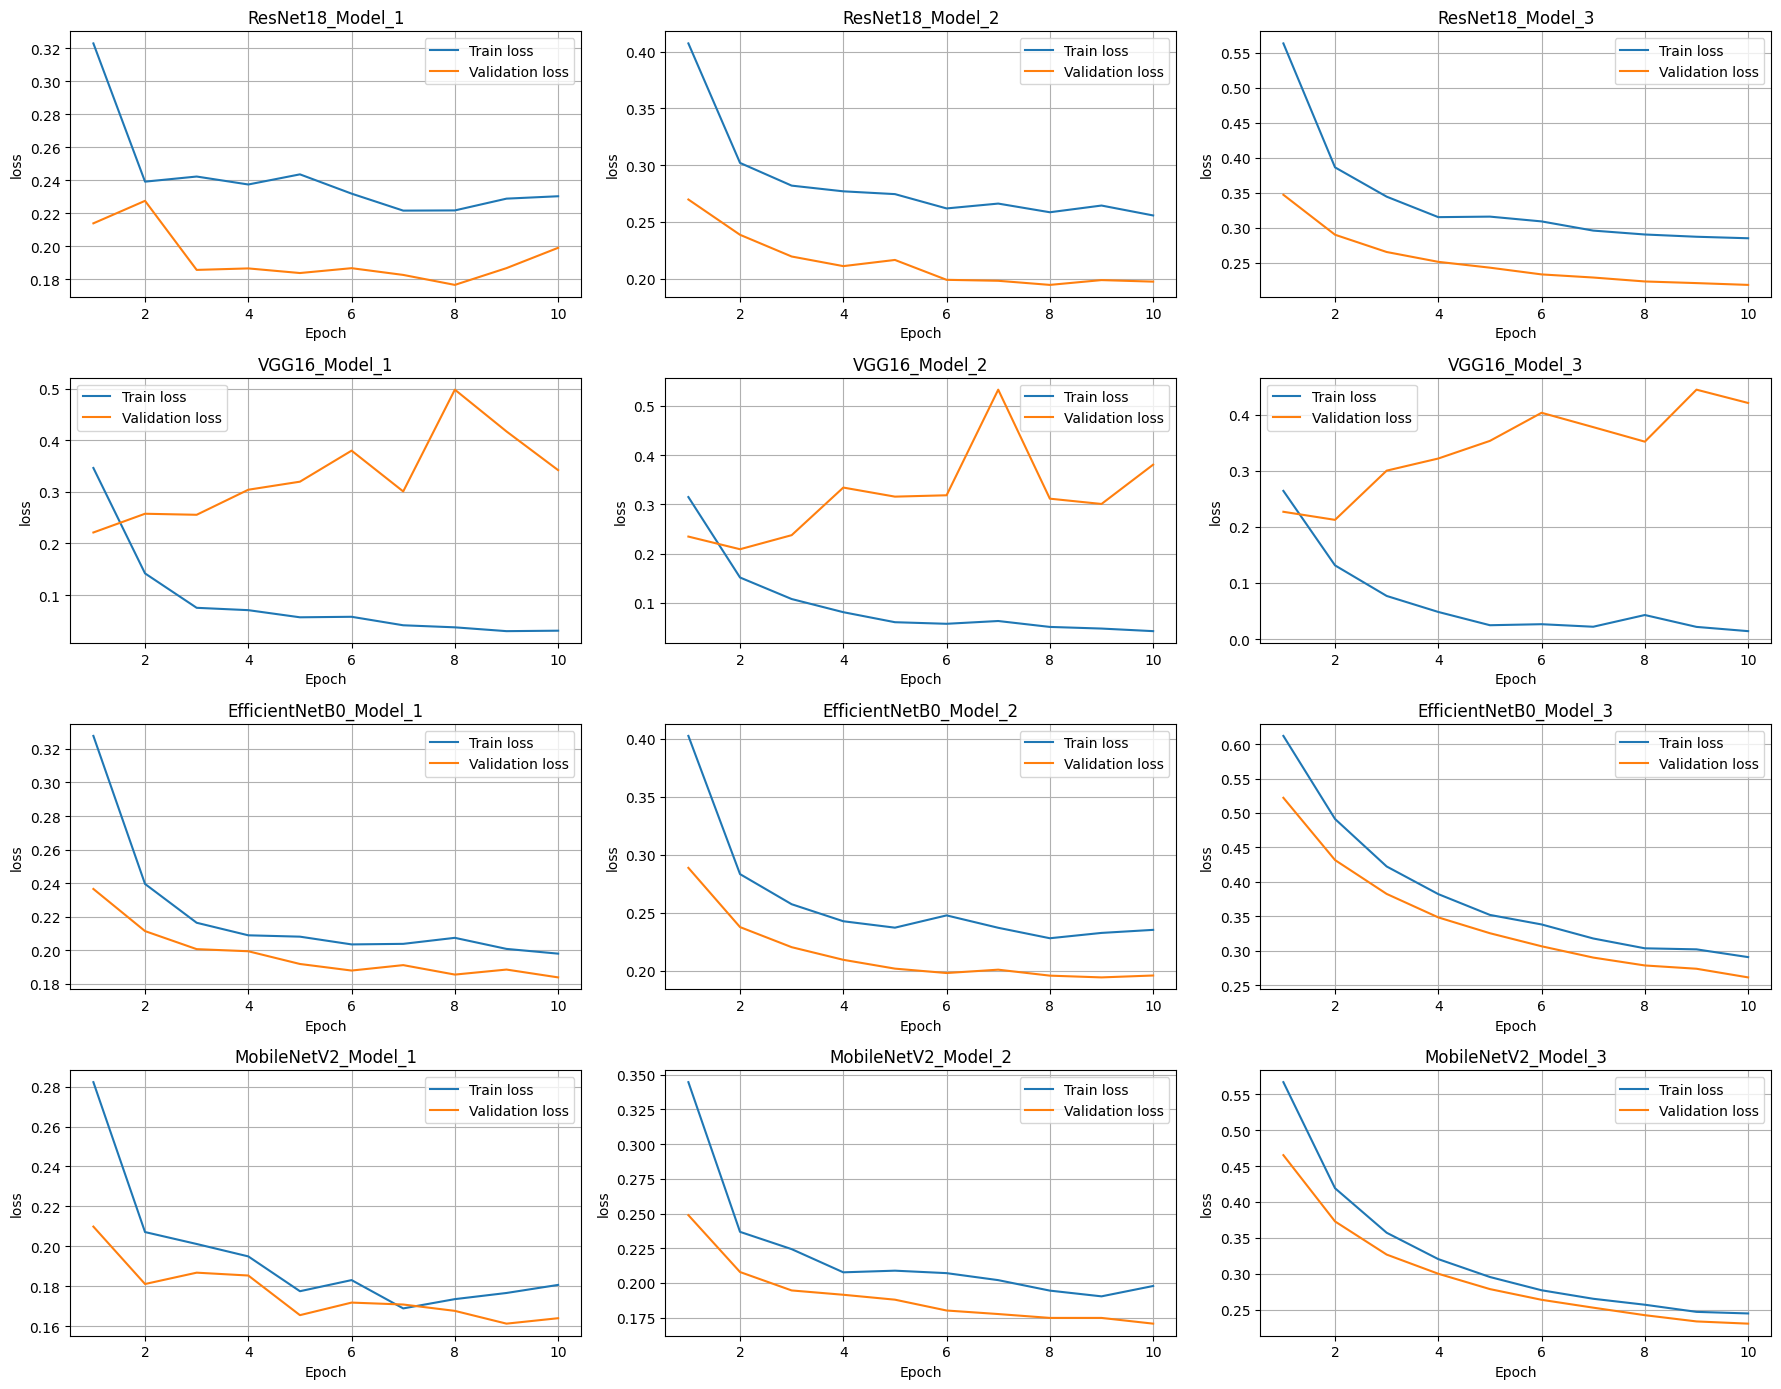

In [23]:
# Choose which metric you want to plot
metric_train = "train_loss"
metric_val = "val_loss"

fig, axes = plt.subplots(4, 3, figsize=(18, 14))

axes = axes.flatten()

for i, (model_name, history) in enumerate(histories.items()):
    ax = axes[i]

    epochs = range(1, len(history[metric_train]) + 1)

    ax.plot(epochs, history[metric_train], label="Train loss")
    ax.plot(epochs, history[metric_val], label="Validation loss")

    ax.set_title(model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("loss")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## Calculating train Metrics

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models_path = "models"
results = []

for experiment in all_experiments:
    for params in experiment["combinations"]:

        model_name = params["model_name"]

        # Create the same model architecture using your built functions
        if "drop_connect_rate" in params:
            model = experiment["create_model"](
                dropout=params["dropout"],
                drop_connect_rate=params["drop_connect_rate"]
            )
        else:
            model = experiment["create_model"](
                dropout=params["dropout"]
            )

        # Load saved model
        model_file = os.path.join(models_path, model_name + ".pth")
        model.load_state_dict(torch.load(model_file, map_location=device))

        model = model.to(device)
        model.eval()

        # Use your built loader function
        train_loader, val_loader, test_loader = create_loaders(
            batch_size=params["batch_size"]
        )

        y_true = []
        y_pred = []

        with torch.no_grad():
            for images, labels in train_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                y_true.extend(labels.cpu().numpy())
                y_pred.extend(predicted.cpu().numpy())

        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted")
        recall = recall_score(y_true, y_pred, average="weighted")
        f1 = f1_score(y_true, y_pred, average="weighted")

        results.append({
            "Model": model_name,
            "Architecture": experiment["architecture"],
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })

train_df = pd.DataFrame(results)

train_df = train_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

train_df

## Calculating Validation Metrics

In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models_path = "models"
results = []

for experiment in all_experiments:
    for params in experiment["combinations"]:

        model_name = params["model_name"]

        # Create the same model architecture using your built functions
        if "drop_connect_rate" in params:
            model = experiment["create_model"](
                dropout=params["dropout"],
                drop_connect_rate=params["drop_connect_rate"]
            )
        else:
            model = experiment["create_model"](
                dropout=params["dropout"]
            )

        # Load saved model
        model_file = os.path.join(models_path, model_name + ".pth")
        model.load_state_dict(torch.load(model_file, map_location=device))

        model = model.to(device)
        model.eval()

        # Use your built loader function
        train_loader, val_loader, test_loader = create_loaders(
            batch_size=params["batch_size"]
        )

        y_true = []
        y_pred = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                y_true.extend(labels.cpu().numpy())
                y_pred.extend(predicted.cpu().numpy())

        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted")
        recall = recall_score(y_true, y_pred, average="weighted")
        f1 = f1_score(y_true, y_pred, average="weighted")

        results.append({
            "Model": model_name,
            "Architecture": experiment["architecture"],
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })

val_df = pd.DataFrame(results)

val_df = val_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

val_df

## Evaluating On test set

In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models_path = "models"
results = []
confusion_matrices = []

for experiment in all_experiments:
    for params in experiment["combinations"]:

        model_name = params["model_name"]

        # Create the same model architecture using your built functions
        if "drop_connect_rate" in params:
            model = experiment["create_model"](
                dropout=params["dropout"],
                drop_connect_rate=params["drop_connect_rate"]
            )
        else:
            model = experiment["create_model"](
                dropout=params["dropout"]
            )

        # Load saved model
        model_file = os.path.join(models_path, model_name + ".pth")
        model.load_state_dict(torch.load(model_file, map_location=device))

        model = model.to(device)
        model.eval()

        # Use your built loader function
        train_loader, val_loader, test_loader = create_loaders(
            batch_size=params["batch_size"]
        )

        y_true = []
        y_pred = []

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                y_true.extend(labels.cpu().numpy())
                y_pred.extend(predicted.cpu().numpy())

        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted")
        recall = recall_score(y_true, y_pred, average="weighted")
        f1 = f1_score(y_true, y_pred, average="weighted")
        cm = confusion_matrix(y_true, y_pred)


        # inside your testing loop, after y_true and y_pred:
        cm = confusion_matrix(y_true, y_pred)

        confusion_matrices.append({
            "model_name": model_name,
            "cm": cm
        })
        results.append({
            "Model": model_name,
            "Architecture": experiment["architecture"],
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })

evaluation_df = pd.DataFrame(results)

evaluation_df = evaluation_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

evaluation_df

,Model,Architecture,Accuracy,Precision,Recall,F1 Score
0,MobileNetV2_Model_2,MobileNetV2,0.9250,0.925002,0.9250,0.925000
1,EfficientNetB0_Model_1,EfficientNetB0,0.9225,0.922500,0.9225,0.922500
2,MobileNetV2_Model_1,MobileNetV2,0.9180,0.918428,0.9180,0.917979
3,EfficientNetB0_Model_2,EfficientNetB0,0.9175,0.917684,0.9175,0.917491
4,MobileNetV2_Model_3,MobileNetV2,0.9175,0.917805,0.9175,0.917485
5,VGG16_Model_1,VGG16,0.9155,0.915620,0.9155,0.915494
6,VGG16_Model_3,VGG16,0.9150,0.915081,0.9150,0.914996
7,ResNet18_Model_2,ResNet18,0.9140,0.914424,0.9140,0.913978
8,VGG16_Model_2,VGG16,0.9100,0.910105,0.9100,0.909994
9,ResNet18_Model_3,ResNet18,0.9070,0.907104,0.9070,0.906994


## Confusion Matrix

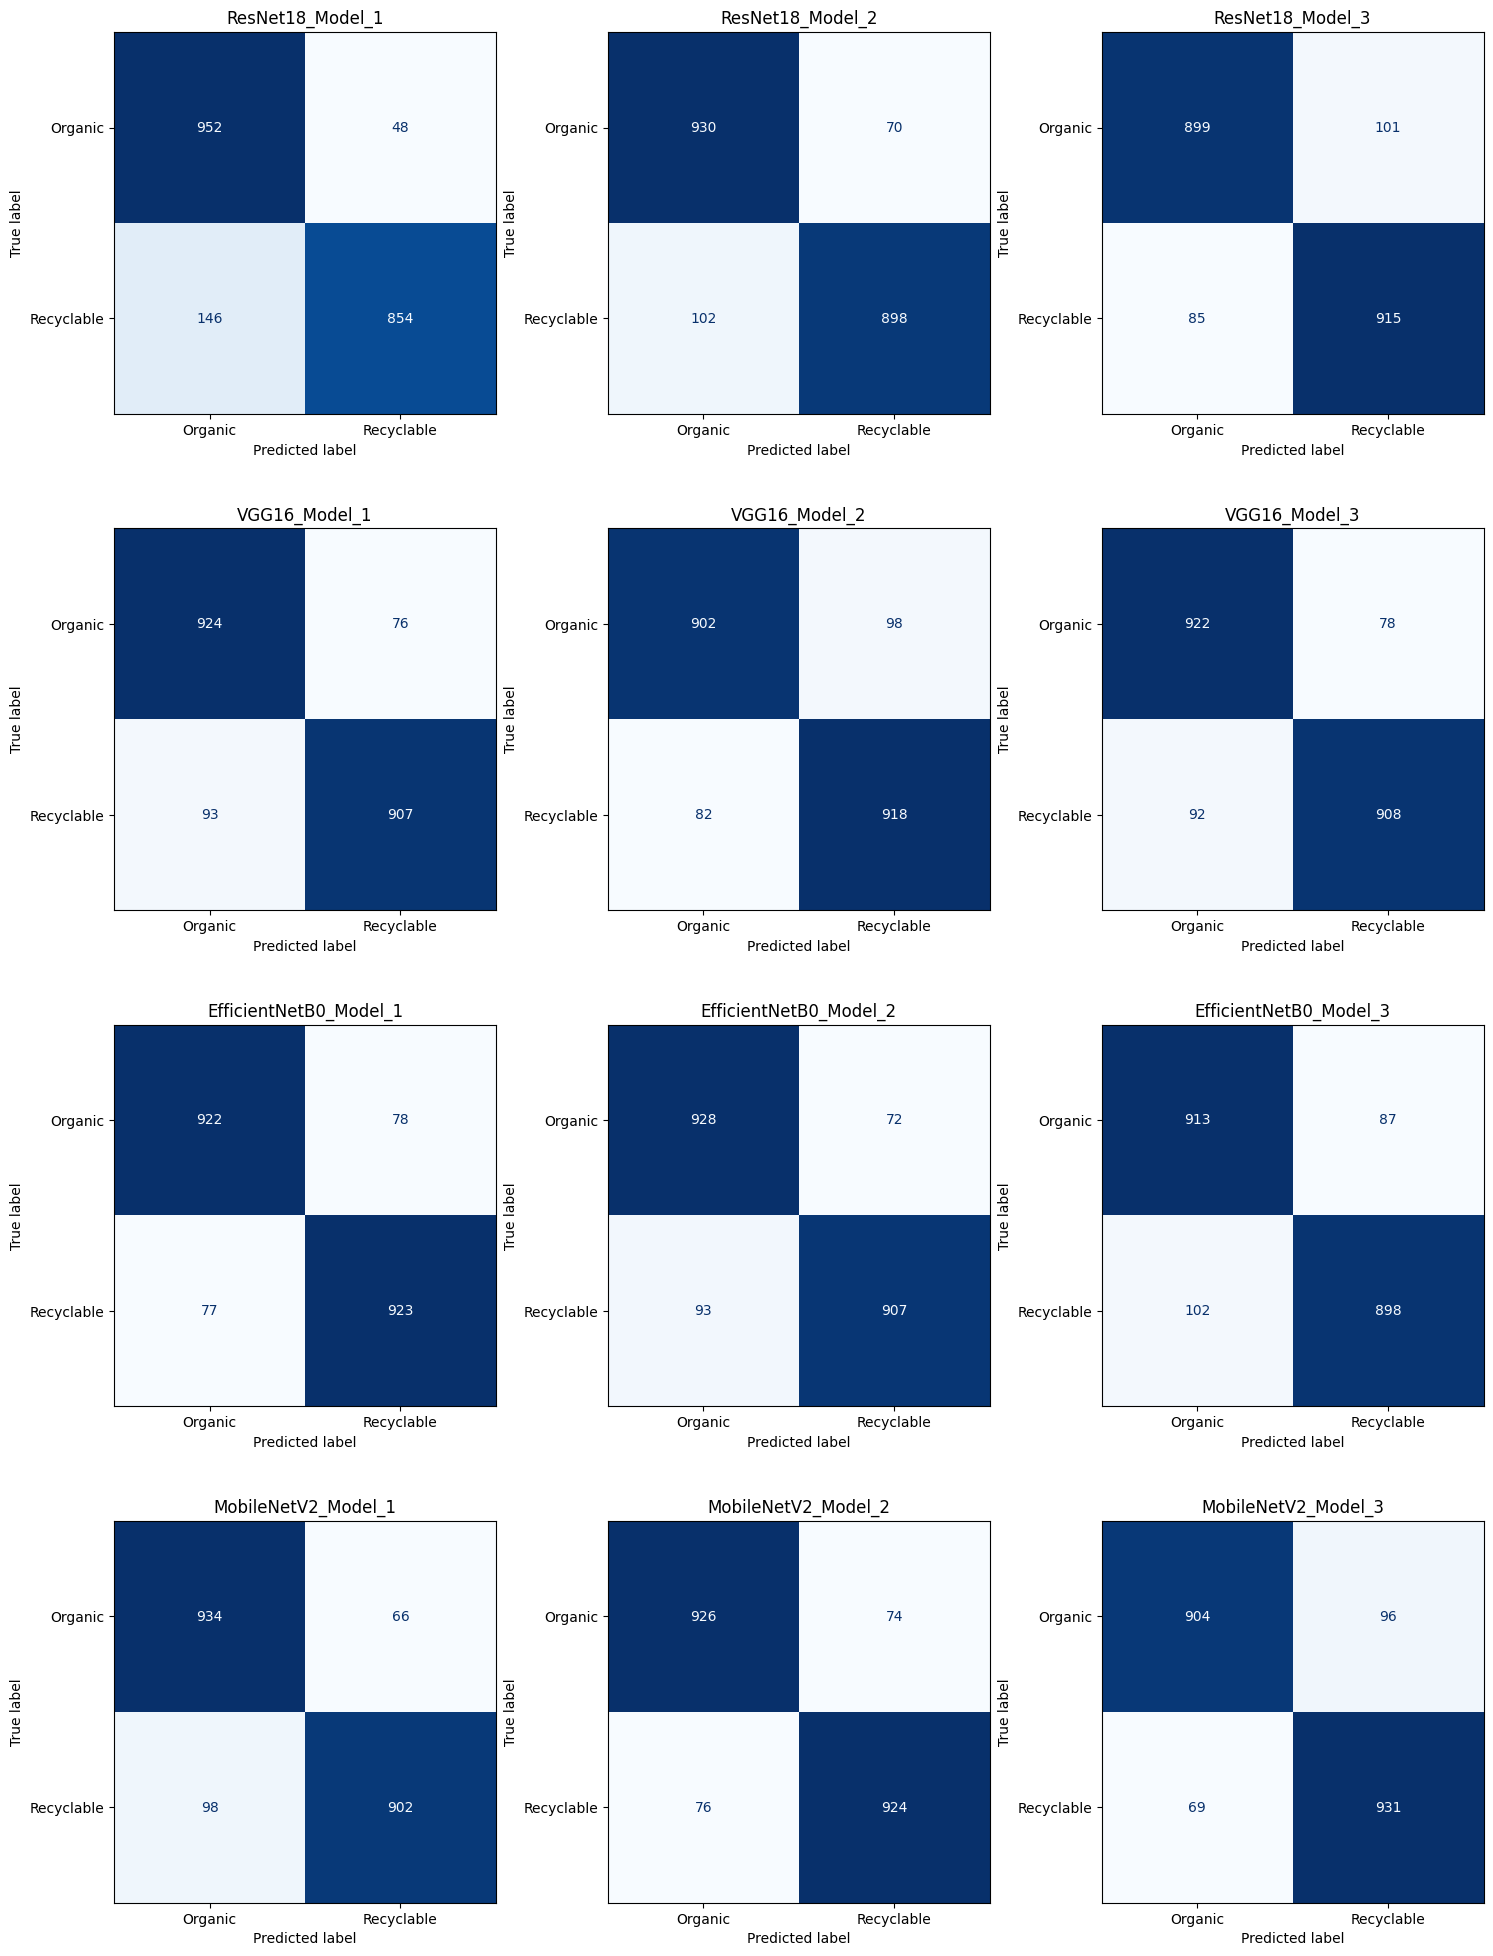

In [ ]:
cols = 3
rows = math.ceil(len(confusion_matrices) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

# Make axes easy to loop over
axes = axes.flatten()

for i, item in enumerate(confusion_matrices):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=item["cm"],
        display_labels=["Organic", "Recyclable"]
    )

    disp.plot(
        ax=axes[i],
        cmap="Blues",
        colorbar=False
    )

    axes[i].set_title(item["model_name"])

# Hide empty subplots if number of models is not divisible by 3
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Summary Table for all the models 

In [37]:
combined_df = train_df.merge(
    val_df,
    on=["Model", "Architecture"],
    suffixes=("_Train", "_Val")
)

combined_df = combined_df.merge(
    evaluation_df,
    on=["Model", "Architecture"]
)

combined_df = combined_df.rename(columns={
    "Accuracy": "Accuracy_Test",
    "Precision": "Precision_Test",
    "Recall": "Recall_Test",
    "F1 Score": "F1 Score_Test"
})

combined_df = combined_df.round(4)

combined_df = combined_df.sort_values(by='Accuracy_Test',ascending=False)

In [39]:
combined_df.to_csv('models_sets_results.csv')

In [40]:
combined_df

,Model,Architecture,Accuracy_Train,Precision_Train,Recall_Train,F1 Score_Train,Accuracy_Val,Precision_Val,Recall_Val,F1 Score_Val,Accuracy_Test,Precision_Test,Recall_Test,F1 Score_Test
5,MobileNetV2_Model_2,MobileNetV2,0.9506,0.9506,0.9506,0.9506,0.937,0.9370,0.937,0.9370,0.9250,0.9250,0.9250,0.9250
4,EfficientNetB0_Model_1,EfficientNetB0,0.9530,0.9530,0.9530,0.9530,0.927,0.9270,0.927,0.9270,0.9225,0.9225,0.9225,0.9225
3,MobileNetV2_Model_1,MobileNetV2,0.9579,0.9580,0.9579,0.9579,0.938,0.9381,0.938,0.9380,0.9180,0.9184,0.9180,0.9180
6,EfficientNetB0_Model_2,EfficientNetB0,0.9427,0.9427,0.9427,0.9427,0.929,0.9292,0.929,0.9290,0.9175,0.9177,0.9175,0.9175
9,MobileNetV2_Model_3,MobileNetV2,0.9279,0.9285,0.9279,0.9278,0.922,0.9224,0.922,0.9220,0.9175,0.9178,0.9175,0.9175
1,VGG16_Model_1,VGG16,0.9979,0.9979,0.9979,0.9979,0.934,0.9346,0.934,0.9340,0.9155,0.9156,0.9155,0.9155
0,VGG16_Model_3,VGG16,0.9991,0.9991,0.9991,0.9991,0.934,0.9343,0.934,0.9340,0.9150,0.9151,0.9150,0.9150
8,ResNet18_Model_2,ResNet18,0.9284,0.9285,0.9284,0.9284,0.928,0.9282,0.928,0.9280,0.9140,0.9144,0.9140,0.9140
2,VGG16_Model_2,VGG16,0.9969,0.9969,0.9969,0.9969,0.925,0.9266,0.925,0.9249,0.9100,0.9101,0.9100,0.9100
11,ResNet18_Model_3,ResNet18,0.9169,0.9171,0.9169,0.9168,0.917,0.9170,0.917,0.9170,0.9070,0.9071,0.9070,0.9070


## Best Models per architecture

In [80]:
# Group by Architecture, get the index of the max Accuracy_Val for each group
best_per_arch = combined_df.loc[combined_df.groupby('Architecture')['Accuracy_Test'].idxmax()]

print(best_per_arch[['Model', 'Architecture', 'Accuracy_Val', 'Precision_Val', 'Recall_Val', 'F1 Score_Val']])

                    Model    Architecture  Accuracy_Val  Precision_Val  \
4  EfficientNetB0_Model_1  EfficientNetB0         0.927         0.9270   
5     MobileNetV2_Model_2     MobileNetV2         0.937         0.9370   
8        ResNet18_Model_2        ResNet18         0.928         0.9282   
1           VGG16_Model_1           VGG16         0.934         0.9346   

   Recall_Val  F1 Score_Val  
4       0.927         0.927  
5       0.937         0.937  
8       0.928         0.928  
1       0.934         0.934  


In [85]:
best_per_arch = best_per_arch.sort_values(by='Accuracy_Test',ascending=False)

In [86]:
best_per_arch.to_csv('best_per_arch.csv')

Best 4 models: ['EfficientNetB0_Model_2', 'MobileNetV2_Model_1', 'ResNet18_Model_2', 'VGG16_Model_1']


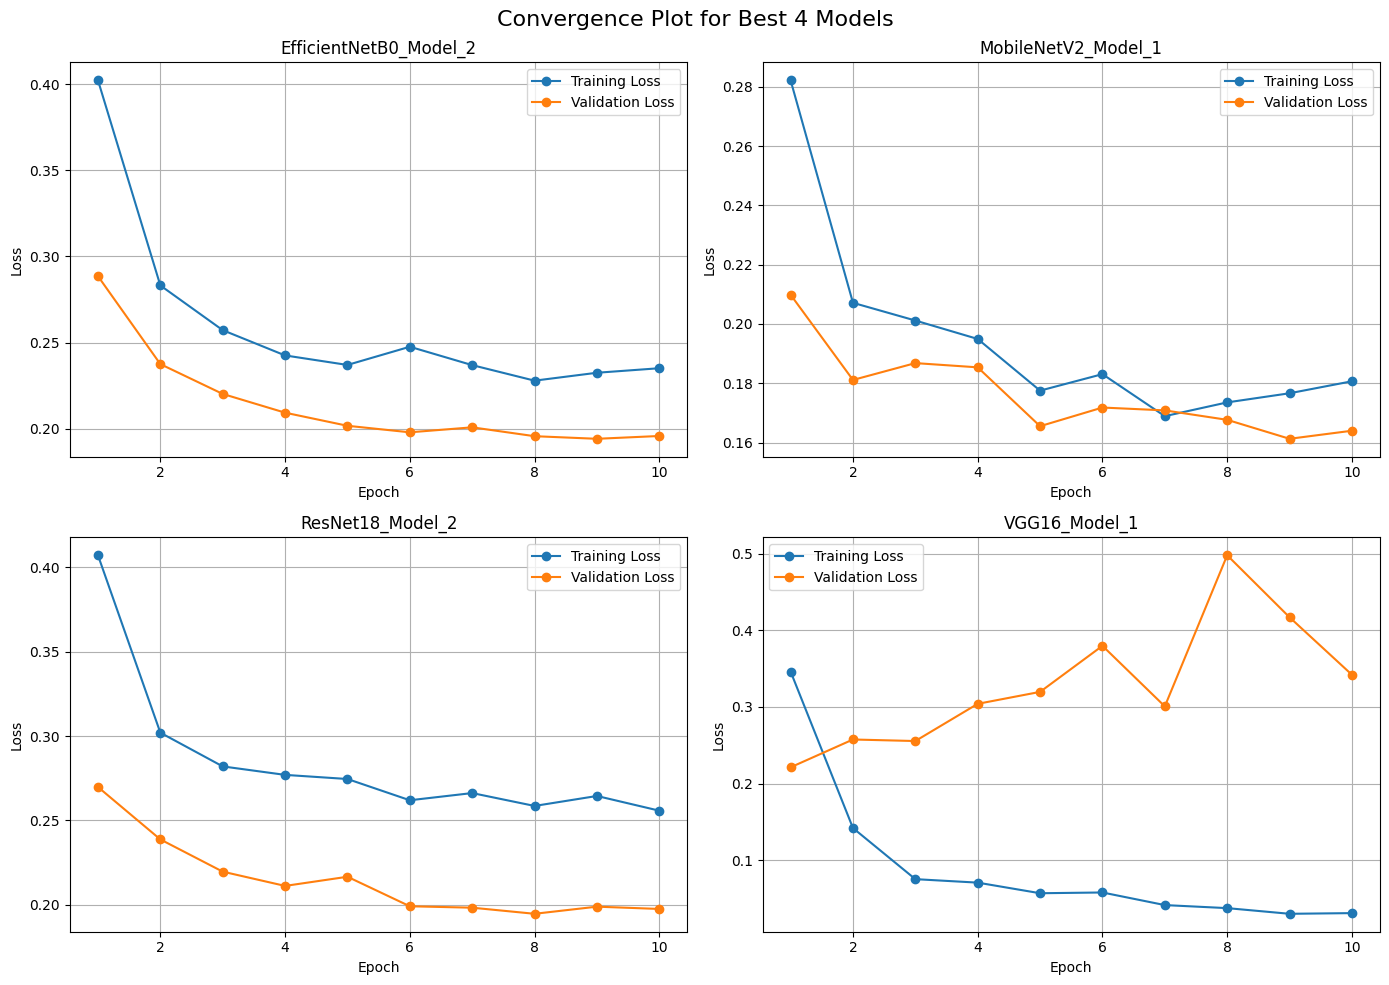

In [ ]:
with open(os.path.join("history", "histories.pkl"), "rb") as f:
    histories = pickle.load(f)

# Select best 4 models based on the evaluation dataframe
best_4_models = best_per_arch['Model'].tolist()

print("Best 4 models:", best_4_models)

# Plot convergence: loss vs epochs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, model_name in enumerate(best_4_models):
    history = histories[model_name]

    epochs = range(1, len(history["train_loss"]) + 1)

    axes[i].plot(epochs, history["train_loss"], marker="o", label="Training Loss")
    axes[i].plot(epochs, history["val_loss"], marker="o", label="Validation Loss")

    axes[i].set_title(model_name)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle("Convergence Plot for Best 4 Models", fontsize=16)
plt.tight_layout()
plt.show()

## Creating Dataset Size vs Model Performance Plot

Best model: MobileNetV2_Model_1
Learning curve for: MobileNetV2_Model_1
Training with 20% of training data
Epoch [1/5] Train Loss: 0.4110 Train Acc: 0.8471 Val Loss: 0.2912 Val Acc: 0.9010
Epoch [2/5] Train Loss: 0.2839 Train Acc: 0.8900 Val Loss: 0.2508 Val Acc: 0.9050
Epoch [3/5] Train Loss: 0.2369 Train Acc: 0.9093 Val Loss: 0.2280 Val Acc: 0.9140
Epoch [4/5] Train Loss: 0.2196 Train Acc: 0.9164 Val Loss: 0.2182 Val Acc: 0.9180
Epoch [5/5] Train Loss: 0.1949 Train Acc: 0.9307 Val Loss: 0.2178 Val Acc: 0.9150
Training with 40% of training data
Epoch [1/5] Train Loss: 0.3541 Train Acc: 0.8689 Val Loss: 0.2467 Val Acc: 0.9160
Epoch [2/5] Train Loss: 0.2505 Train Acc: 0.9054 Val Loss: 0.2212 Val Acc: 0.9190
Epoch [3/5] Train Loss: 0.2111 Train Acc: 0.9214 Val Loss: 0.1992 Val Acc: 0.9250
Epoch [4/5] Train Loss: 0.2058 Train Acc: 0.9282 Val Loss: 0.1982 Val Acc: 0.9200
Epoch [5/5] Train Loss: 0.1960 Train Acc: 0.9279 Val Loss: 0.1950 Val Acc: 0.9190
Training with 60% of training data
Epo

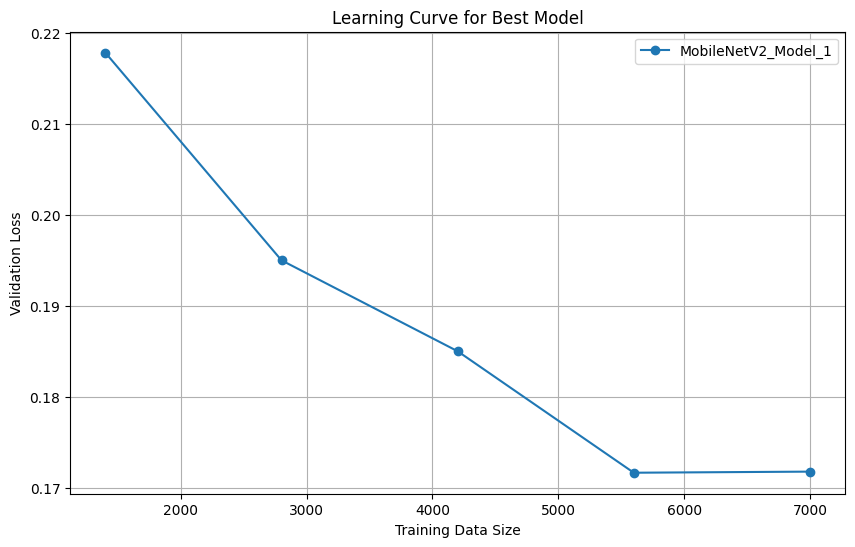

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Best 4 models from your evaluation dataframe
best_model = best_per_arch.sort_values(by = 'Accuracy_Val',ascending=False)['Model'].head(1).tolist()[0]

print("Best model:", best_model)

# Data sizes to try
data_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]

learning_curve_results = {}

# Use fewer epochs because this will retrain many times
learning_curve_epochs = 5

for experiment in all_experiments:
    for params in experiment["combinations"]:
        if params['model_name'] != best_model:
            continue

        model_name = params['model_name']

        print("=" * 60)
        print("Learning curve for:", model_name)

        model_losses = []
        model_data_amounts = []

        for size in data_sizes:

            print(f"Training with {int(size * 100)}% of training data")

            organic_count = int(len(train_organic) * size)
            recyclable_count = int(len(train_recyclable) * size)

            small_train_dataset = WasteDataset(
                organic_dir=organic_dir,
                recyclable_dir=recyclable_dir,
                organic_files=train_organic[:organic_count],
                recyclable_files=train_recyclable[:recyclable_count],
                transform=transform
            )

            small_train_loader = DataLoader(
                small_train_dataset,
                batch_size=params["batch_size"],
                shuffle=True
            )

            val_loader = DataLoader(
                val_dataset,
                batch_size=params["batch_size"],
                shuffle=False
            )

            # Create model using your built functions
            if "drop_connect_rate" in params:
                model = experiment["create_model"](
                    dropout=params["dropout"],
                    drop_connect_rate=params["drop_connect_rate"]
                )
            else:
                model = experiment["create_model"](
                    dropout=params["dropout"]
                )

            trained_model, history = train_one_model(
                model=model,
                train_loader=small_train_loader,
                val_loader=val_loader,
                params=params,
                epochs=learning_curve_epochs,
                device=device
            )

            final_val_loss = history["val_loss"][-1]

            model_losses.append(final_val_loss)
            model_data_amounts.append(len(small_train_dataset))

        learning_curve_results[model_name] = {
            "data_amounts": model_data_amounts,
            "val_losses": model_losses
        }

# Plot learning curve
plt.figure(figsize=(10, 6))

for model_name, result in learning_curve_results.items():
    plt.plot(
        result["data_amounts"],
        result["val_losses"],
        marker="o",
        label=model_name
    )

plt.title("Learning Curve for Best Model")
plt.xlabel("Training Data Size")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## Test Results

In [58]:
combined_df[['Model','Architecture','Accuracy_Test','Recall_Test','Precision_Test','F1 Score_Test']]

,Model,Architecture,Accuracy_Test,Recall_Test,Precision_Test,F1 Score_Test
5,MobileNetV2_Model_2,MobileNetV2,0.9250,0.9250,0.9250,0.9250
4,EfficientNetB0_Model_1,EfficientNetB0,0.9225,0.9225,0.9225,0.9225
3,MobileNetV2_Model_1,MobileNetV2,0.9180,0.9180,0.9184,0.9180
6,EfficientNetB0_Model_2,EfficientNetB0,0.9175,0.9175,0.9177,0.9175
9,MobileNetV2_Model_3,MobileNetV2,0.9175,0.9175,0.9178,0.9175
1,VGG16_Model_1,VGG16,0.9155,0.9155,0.9156,0.9155
0,VGG16_Model_3,VGG16,0.9150,0.9150,0.9151,0.9150
8,ResNet18_Model_2,ResNet18,0.9140,0.9140,0.9144,0.9140
2,VGG16_Model_2,VGG16,0.9100,0.9100,0.9101,0.9100
11,ResNet18_Model_3,ResNet18,0.9070,0.9070,0.9071,0.9070


## Calculating Time and Size

In [89]:
!pip install torchinfo

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

epochs = 10

trained_models = {}
histories = {}

results = []

os.makedirs("models", exist_ok=True)

best_4_model_names = [
    "MobileNetV2_Model_2",
    "EfficientNetB0_Model_1",
    "ResNet18_Model_2",
    "VGG16_Model_1"
]

for experiment in all_experiments:
    print("#" * 60)
    print("Architecture:", experiment["architecture"])
    print("#" * 60)

    for params in experiment["combinations"]:

        model_name = params["model_name"]

        # Train only the best 4 models
        if model_name not in best_4_model_names:
            continue

        print("=" * 60)
        print("Training:", model_name)
        print(params)

        train_loader, val_loader, test_loader = create_loaders(
            batch_size=params["batch_size"]
        )

        if "drop_connect_rate" in params:
            model = experiment["create_model"](
                dropout=params["dropout"],
                drop_connect_rate=params["drop_connect_rate"]
            )
        else:
            model = experiment["create_model"](
                dropout=params["dropout"]
            )

        model = model.to(device)

        # Get model summary before training
        model_summary = summary(
            model,
            input_size=(1, 3, 224, 224),
            verbose=0
        )

        total_params = model_summary.total_params
        trainable_params = model_summary.trainable_params

        # Measure training time
        start_time = time.time()

        trained_model, history = train_one_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            params=params,
            epochs=epochs,
            device=device
        )

        end_time = time.time()

        training_time_seconds = end_time - start_time
        training_time_minutes = training_time_seconds / 60

        trained_models[model_name] = trained_model
        histories[model_name] = history

        save_path = os.path.join("models", model_name + ".pth")

        model_size_mb = os.path.getsize(save_path) / (1024 * 1024)

        results.append({
            "Model Name": model_name,
            "Architecture": experiment["architecture"],
            "Total Parameters": total_params,
            "Trainable Parameters": trainable_params,
            "Saved Model Size (MB)": model_size_mb,
            "Training Time (Seconds)": training_time_seconds,
            "Training Time (Minutes)": training_time_minutes
        })
        print("Training time:", round(training_time_minutes, 2), "minutes")
        print("Model size:", round(model_size_mb, 2), "MB")

Using device: cuda
############################################################
Architecture: ResNet18
############################################################
Training: ResNet18_Model_2
{'model_name': 'ResNet18_Model_2', 'dropout': 0.4, 'learning_rate': 0.0005, 'batch_size': 32, 'momentum': 0.85}
Epoch [1/10] Train Loss: 0.4220 Train Acc: 0.8080 Val Loss: 0.2769 Val Acc: 0.9050
Epoch [2/10] Train Loss: 0.3028 Train Acc: 0.8761 Val Loss: 0.2339 Val Acc: 0.9140
Epoch [3/10] Train Loss: 0.2882 Train Acc: 0.8830 Val Loss: 0.2182 Val Acc: 0.9180
Epoch [4/10] Train Loss: 0.2712 Train Acc: 0.8859 Val Loss: 0.2166 Val Acc: 0.9250
Epoch [5/10] Train Loss: 0.2720 Train Acc: 0.8933 Val Loss: 0.2088 Val Acc: 0.9180
Epoch [6/10] Train Loss: 0.2630 Train Acc: 0.8924 Val Loss: 0.2085 Val Acc: 0.9250
Epoch [7/10] Train Loss: 0.2684 Train Acc: 0.8970 Val Loss: 0.1990 Val Acc: 0.9270
Epoch [8/10] Train Loss: 0.2653 Train Acc: 0.8941 Val Loss: 0.1965 Val Acc: 0.9260
Epoch [9/10] Train Loss: 0.2582 T

In [ ]:
best_4_model_names = [
    "MobileNetV2_Model_2",
    "EfficientNetB0_Model_1",
    "ResNet18_Model_2",
    "VGG16_Model_1"
]

for name in best_4_model_names:
    path = os.path.join("models", name + ".pth")

    state_dict = torch.load(path)

    total_params = 0

    for tensor in state_dict.values():
        total_params += tensor.numel()

    print(f"Number of parameters for {name}: {total_params:,}")

Number of parameters for MobileNetV2_Model_2: 2,260,598
Number of parameters for EfficientNetB0_Model_1: 4,052,175
Number of parameters for ResNet18_Model_2: 11,187,158
Number of parameters for VGG16_Model_1: 121,676,610
